# Signal Peptide Prediction: A Comparative Analysis of von Heijne's method and SVM model
## Daniele Ganci
#### Department of Farmacy and Biotechnology – FaBit, University of Bologna, Via Selmi 3 (BO)


This jupyter file implements and evaluates two methods for signal peptide (SP) prediction: the von Heijne weight matrix approach and a Support Vector Machine (SVM) model with a Radial Basis Function (RBF) kernel. It compares their accuracy in identifying SPs and cleavage sites, focusing on distinguishing SPs from similar N-terminal transmembrane helices. Results highlight the SVM model as a more accurate and reliable tool for SP prediction, contributing to advancements in computational protein localization methods.

### Dependencies

In [ ]:
%%capture
!pip install Bio

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import sys
import requests
from requests.adapters import HTTPAdapter, Retry
import json
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
from collections import Counter
from sklearn import svm, preprocessing
from sklearn.metrics import precision_recall_curve, matthews_corrcoef, accuracy_score, f1_score
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from Bio.SeqUtils import ProtParamData

## 1. Data loading and preprocessing

This code sets up an HTTP session with automatic retries (up to 5 times) for server errors and incremental backoff. It also includes a function to extract the "next" link from response headers for paginated API requests.

In [ ]:
retries = Retry(total=5, backoff_factor=0.25, status_forcelist=[500, 502, 503, 504])
session = requests.Session()
session.mount("https://", HTTPAdapter(max_retries=retries))

def get_next_link(headers):
  if "Link" in headers:
    # The regular expression is used to extract the next link for pagination
    re_next_link = re.compile(r'<(.+)>; rel="next"')
    match = re_next_link.match(headers["Link"])
    if match:
      return match.group(1)

This function retrieves data in batches from a paginated API by making HTTP GET requests, ensuring successful responses, and yielding both the response and the total number of entries. It automatically updates the URL to fetch the next batch using the pagination link from the response headers.

In [ ]:
def get_batch(batch_url):
  while batch_url:
    # Run the API call
    response = session.get(batch_url)

    # Will raise an error if an error status code is obtained
    response.raise_for_status()

    # Get the total number of entries in the search
    total = response.headers["x-total-results"]

    # Yield the response and the total number of entries
    yield response, total

    # Get the link to the API call for the next data batch
    batch_url = get_next_link(response.headers)

This function filters entries to identify those containing a valid signal peptide. It checks if the feature type is "Signal", ensures the peptide is at least 14 bases long, and confirms the peptide hasn't been cleaved (based on an empty description). If all conditions are met, it returns `True`; otherwise, it returns `False`.

In [ ]:
def filter_entry(entry):
  # We iterate over the features of the entry
  for feature in entry["features"]:
    # We only consider features of type Signal
    if feature["type"] == "Signal":
      start = feature["location"]["start"]["value"]
      end = feature["location"]["end"]["value"]
      # Check if the Signal peptide is at least 14 bases and check the peptide isn't cleaved
      if isinstance(start, int) and isinstance(end, int):
        if (end - start + 1) > 13 and feature["description"] == "":
          return True
  return False

This function extracts various fields from a biological data entry. It retrieves the accession, organism name, eukaryotic kingdom based on the organism's lineage, and protein length. If the `pos` argument is `True`, it returns the position of the signal peptide cleavage site; otherwise, it checks if a transmembrane feature with a helical description exists and if its start position is less than or equal to 90. It returns all the extracted values in a tuple.

In [ ]:
def extract_fields(entry, pos):

  #accession
  a = entry["primaryAccession"]

  # organism name
  o = entry["organism"]["scientificName"]

  # eukariotic kingdom
  if "Metazoa" in entry["organism"]["lineage"]:
    k = "Metazoa"
  elif "Viridiplantae" in entry["organism"]["lineage"]:
    k = "Viridiplantae"
  elif "Fungi" in entry["organism"]["lineage"]:
    k = "Fungi"
  else:
    k = "Other"

  #protein lenght
  l = entry["sequence"]["length"]

  if pos:
    # position of the signal peptide clivage site
    pcs = entry["features"][0]["location"]["end"]["value"]

  else:
    tm = False
    for f in entry["features"]:
      if f["type"]=="Transmembrane":
        if re.search("Helical",f["description"]):
          if f["location"]["start"]["value"]<=90:
            tm = True

  return a, o, k, l, (pcs if pos else tm)

This code defines a series of functions for fetching, filtering, and saving biological data. Here's a brief overview of each:

1. **get_filtered_entries**: Fetches entries in batches from an API, filtering them based on the presence of a signal peptide (if `pos` is `True`) or appending all entries (if `pos` is `False`). It returns the filtered/unfiltered entries along with the counts.

2. **write_tsv**: Writes the filtered or unfiltered entries to a TSV file. If `pos` is `True`, it writes signal peptide cleavage site data; otherwise, it writes information on transmembrane helix positions.

3. **write_fasta**: Writes the entries to a FASTA file, including the protein sequence and primary accession.

4. **get_dataset**: Combines the functions above to fetch the dataset, log the counts, and write the results to both a TSV and FASTA file.

In [ ]:
def get_filtered_entries(url, pos):

  all_entries = []
  n_total, n_filtered = 0, 0

  # Run the API call in batches
  for batch, total in get_batch(url):
    batch_json = json.loads(batch.text)
    for entry in batch_json["results"]:
      n_total += 1
      if pos:
        if filter_entry(entry):
          n_filtered += 1
          all_entries.append(entry)
      else:
        all_entries.append(entry)

  return all_entries, n_total, (n_filtered if pos else 0)

def write_tsv(output_tsv, entries, pos):

  with open(output_tsv, "w") as ofs:
    if pos:
      ofs.write("Accession\tOrganism\tKingdom\tLength\tSignalPeptideCleavageSite\n")
    else:
      ofs.write("Accession\tOrganism\tKingdom\tLength\tHelixStartPos<90\n")

    n_tra_helix = 0
    for entry in entries:
      fields = extract_fields(entry, pos)
      print(*fields, sep="\t", file=ofs)
      if not pos and fields[4]:
        n_tra_helix += 1
    if not pos:
      print('Number of transmembrane helixes =', n_tra_helix)

def write_fasta(output_fasta, entries):

  with open(output_fasta, "w") as fas:
    for entry in entries:
      print('>sp|%s|' % entry["primaryAccession"], '\n', entry['sequence']['value'], file=fas)

def get_dataset(url, output_tsv, output_fasta, pos):

  # Get filtered or unfiltered entries
  entries, n_total, n_filtered = get_filtered_entries(url, pos)

  # Log total and filtered counts
  if pos:
    print('Positives:', '\nTotal counts =', n_total, '\nFiltered counts =', n_filtered)
  else:
    print('\nNegatives:', '\nTotal counts =', n_total)

  # Write output files
  write_tsv(output_tsv, entries, pos)
  write_fasta(output_fasta, entries)

This code retrieves and processes biological data from the UniProt database in two parts: positives and negatives.

1. **Positives**: It fetches proteins from the taxonomy group "Homo sapiens" (taxonomy ID 2759) that have a signal peptide (ft_signal_exp:*), are of sufficient length (≥40), have confirmed existence, are non-fragmented, and are reviewed in UniProt. It calls the get_dataset function with the appropriate URL to save the results in a positives.tsv and positives.fasta file.

2. **Negatives**: It retrieves proteins that belong to the same taxonomy group, have confirmed existence, are non-fragmented, and are reviewed, but do not contain a signal peptide (NOT(ft_signal:*)). Additionally, it filters proteins that have certain terms in the cc_scl_term_exp (subcellular localization). It saves these results in negatives.tsv and negatives.fasta.

In [ ]:
batch_size = 500

#Positives
url = f'https://rest.uniprot.org/uniprotkb/search?format=json&query=%28%28taxonomy_id%3A2759%29+AND+%28ft_signal_exp%3A*%29+AND+%28length%3A%5B40+TO+*%5D%29+AND+%28existence%3A1%29+AND+%28fragment%3Afalse%29+AND+%28reviewed%3Atrue%29%29&size={batch_size}'
get_dataset(url, 'positives.tsv', 'positives.fasta', True)

# Negatives
url = f"https://rest.uniprot.org/uniprotkb/search?format=json&query=((existence%3A1)+AND+(taxonomy_id%3A2759)+AND+(length%3A[40+TO+*])+AND+(fragment%3Afalse)+AND+(reviewed%3Atrue)+AND+(cc_scl_term_exp%3ASL-0091+OR+cc_scl_term_exp%3ASL-0191+OR+cc_scl_term_exp%3ASL-0173+OR+cc_scl_term_exp%3ASL-0209+OR+cc_scl_term_exp%3ASL-0204+OR+cc_scl_term_exp%3ASL-0039)+NOT+(ft_signal%3A*))&size={batch_size}"
get_dataset(url, 'negatives.tsv', 'negatives.fasta', False)

Positives: 
Total counts = 2926 
Filtered counts = 2909

Negatives: 
Total counts = 20235
Number of transmembrane helixes = 2387


This code filters protein data by matching UniProt IDs from FASTA files to TSV files. It labels the filtered positive and negative entries (1 for positive, 0 for negative) and saves them as new TSV files. Finally, it concatenates the corresponding FASTA files (`positives.fasta` and `negatives.fasta`) into a single `pos+neg.fasta` file.

In [ ]:
def get_ids(file):
  '''Generates a UniProt ids generator'''
  with open(file) as f:
   for line in f:
     if line.startswith('>'):
      id = line[1:].rstrip()
      yield id

def filter_tsv(input_tsv, file, output_tsv):
  ids = set(get_ids(file))
  df = pd.read_csv(input_tsv, sep='\t')
  df[df['Accession'].isin(ids)].to_csv(output_tsv, sep='\t', index=False)

filter_tsv('positives.tsv', 'pos_cluster-results_rep_seq.fasta', 'pos_filt.tsv')
filter_tsv('negatives.tsv', 'neg_cluster-results_rep_seq.fasta', 'neg_filt.tsv')

pos_filt = pd.read_csv('pos_filt.tsv', sep='\t')
pos_filt['label'] = 1

neg_filt = pd.read_csv('neg_filt.tsv', sep='\t')
neg_filt['label'] = 0

# concatenate the fasta files
with open('pos+neg.fasta', 'w') as out:
  with open('positives.fasta') as f1: out.write(f1.read())
  with open('negatives.fasta') as f2: out.write(f2.read())

This code splits the data into training, validation, and testing sets. Positive and negative samples are split independently: 80% training and 20% testing for the final sets, and 60% training, 20% validation, and 20% testing for parameter optimization. The subsets are combined into `train_set`, `val_set`, and `test_set`, with "Accession" as the index.

In [ ]:
def split(data, size):
  split = data.sample(n=int(len(data)*size), random_state=123)
  return split, data.drop(split.index)

# Final training and testing sets

# Train 80%, Test 20%
final_test_pos, final_train_pos = split(pos_filt, 0.2)
final_test_neg, final_train_neg = split(neg_filt, 0.2)

# whole sets
final_train_set = pd.concat([final_train_pos, final_train_neg]).set_index('Accession')
final_test_set = pd.concat([final_test_pos, final_test_neg]).set_index('Accession')

# Parameters optimization phase sets

# Train 60%, Validation 20%, Test 20%
pos_test, tmp = split(final_train_pos, 0.2)
pos_val, pos_train = split(tmp, 0.25)

neg_test, tmp = split(final_train_neg, 0.2)
neg_val, neg_train = split(tmp, 0.25)

# whole sets
train_set = pd.concat([pos_train, neg_train]).set_index('Accession')
val_set = pd.concat([pos_val, neg_val]).set_index('Accession')
test_set = pd.concat([pos_test, neg_test]).set_index('Accession')

This code performs k-fold cross-validation (default 5 folds) on the training, validation, and test sets. It shuffles the dataset, assigns each entry to a fold, and ensures that each fold contains approximately the same number of samples. The resulting dataframes have an additional column `cv_fold` indicating the fold number for each entry, and they are indexed by `Accession` for consistency.

In [ ]:
def cross_val(df, k=5):

  # Shuffle the dataframe
  df = df.sample(frac=1, random_state=42).reset_index(drop=False)

  # CV column set at -1
  df['cv_fold'] = -1

  sizes = np.full(k, len(df) // k)
  sizes[:len(df) % k] += 1 # recover the residual elements

  # Initialize the limits for each fold
  current = 0
  for fold, size in enumerate(sizes):
    df.loc[current:current + size - 1, 'cv_fold'] = fold
    current += size

  df = df.set_index('Accession')

  return df

train_cv = cross_val(train_set)
val_cv = cross_val(val_set)
test_cv = cross_val(test_set)

final_train_cv = cross_val(final_train_set)
final_test_cv = cross_val(final_test_set)

## 2. Data visualization

This code visualizes the distributions of protein lengths and signal peptide cleavage site positions in both positive and negative training and test sets. It uses histograms with kernel density estimates (KDE) and boxplots grouped by the 'Kingdom' column for comparison. The `plot_distrib` function is applied to each dataset, with adjustable bin width and axis limits for each feature. The plots are organized in a 6x2 grid, displaying the distributions of the relevant features across the sets. Finally, `plt.tight_layout()` ensures that the plots are neatly arranged, and `plt.show()` renders the visuals.

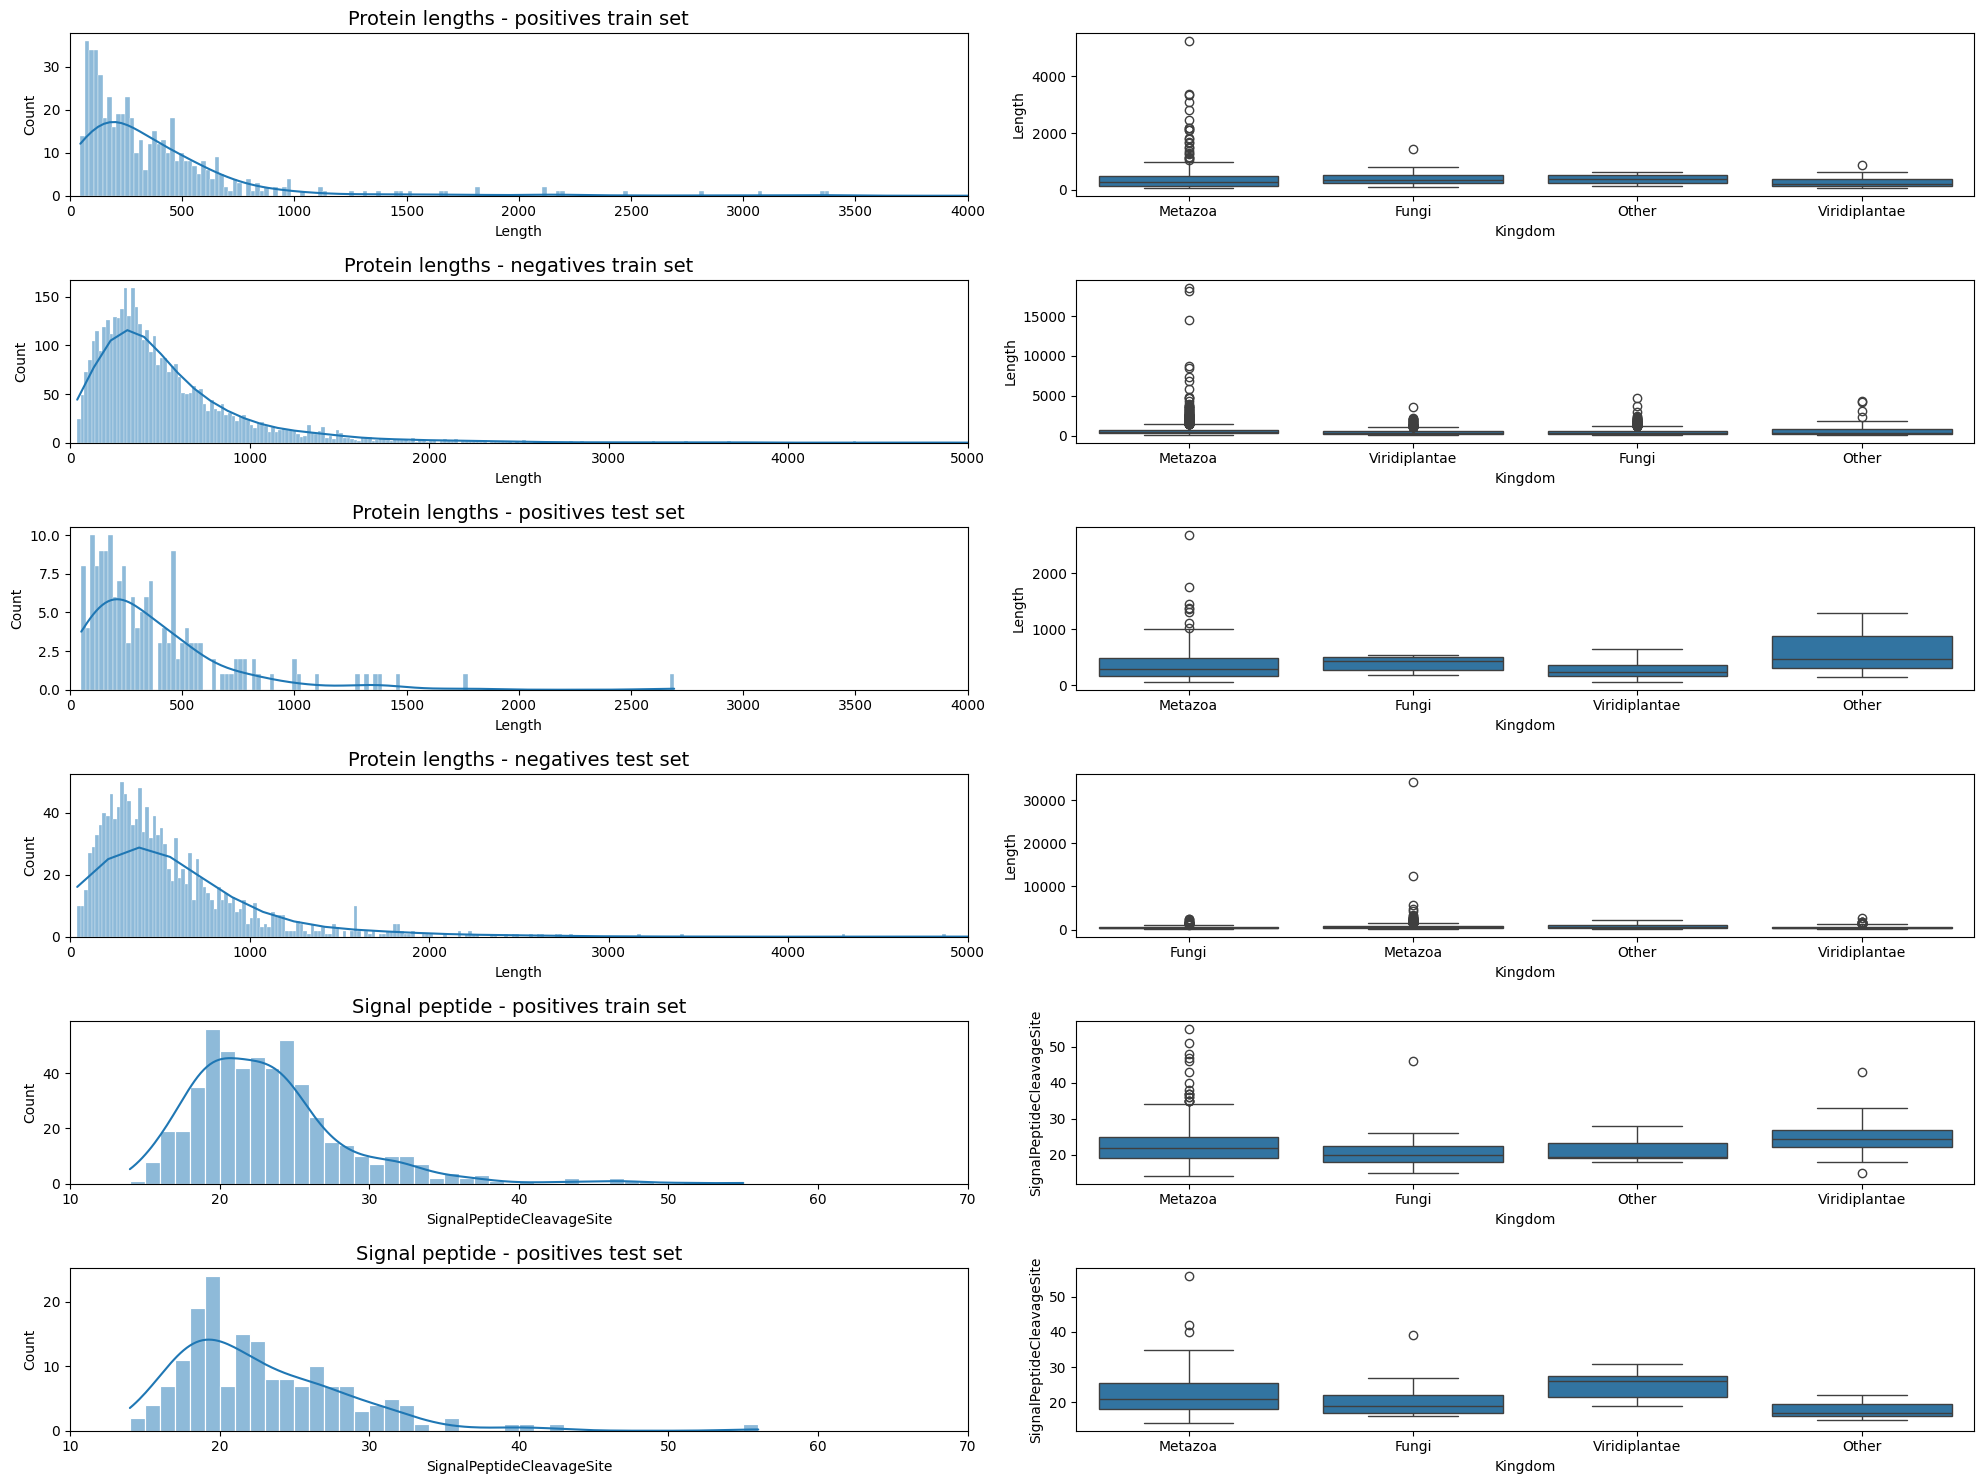

In [ ]:
def plot_distrib(data, col, title, binwidth, minlim, maxlim, axes=None):
    sns.set_theme(style="darkgrid", palette='deep')

    if axes is None:
        fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

    axes[0].set_xlim(minlim, maxlim)

    sns.histplot(data[col], binwidth=binwidth, kde=True, ax=axes[0])
    sns.boxplot(data=data, x='Kingdom', y=col, ax=axes[1])

    axes[0].set_title(title, fontsize=14)

    return axes

fig, axs = plt.subplots(6, 2, figsize=(20, 15))

plot_distrib(pos_train, 'Length', 'Protein lengths - positives train set', 20, 0, 4000, axes=axs[0])
plot_distrib(neg_train, 'Length', 'Protein lengths - negatives train set', 20, 0, 5000, axes=axs[1])

plot_distrib(pos_test, 'Length', 'Protein lengths - positives test set', 20, 0, 4000, axes=axs[2])
plot_distrib(neg_test, 'Length', 'Protein lengths - negatives test set', 20, 0, 5000, axes=axs[3])

plot_distrib(pos_train, 'SignalPeptideCleavageSite', 'Signal peptide - positives train set', 1, 10, 70, axes=axs[4])
plot_distrib(pos_test, 'SignalPeptideCleavageSite', 'Signal peptide - positives test set', 1, 10, 70, axes=axs[5])

plt.tight_layout()
plt.show()

The `sp_info` function processes protein sequence data to return two dictionaries:

1. `aa_count` - the frequency of amino acids before the signal peptide cleavage site (normalized to percentages).
2. `motif_dct` - maps protein IDs to their cleavage site motif and associated cross-validation fold.

It iterates over protein sequences in `positives.fasta`, updating the dictionaries based on cleavage site position and fold information from the data. The function is called for different data splits (train and test), with results stored in `aa_count_train`, `motif_train`, `aa_count_test`, and `motif_test`.

In [ ]:
def sp_info(data) -> tuple[dict, dict]:
  '''Returns a tuple of dictionaries: ({aa: count}, {id: (motif, fold)})'''

  dct = {
      id: (pos, fold)
      for id, pos, fold in zip(data.index, data['SignalPeptideCleavageSite'], data['cv_fold'])
      if pd.notna(pos) # take only the positives
      }

  # Initialize the dictionaries
  counter = Counter()
  motif_dct = {}

  # Update the dictionaries
  with open('positives.fasta') as f:
    prev = None

    for line in f:
      if prev and prev.startswith('>'):
        id = prev.split('|')[1]
        if id in dct:

          pos = int(dct[id][0])
          fold = dct[id][1]

          # update the counter
          seq = line[:pos].strip()
          counter.update(seq)

          # retrieve the motifs
          motif = line[pos-13:pos+2].strip()
          motif_dct[id] = (motif, fold)

      prev = line

  tot = sum(counter.values())

  return {k: v/tot*100 for k, v in counter.items()}, motif_dct

# SP info - train
_, motif_train = sp_info(train_cv)
aa_count_train, motif_final_train = sp_info(final_train_cv)

# SP info - test
_, motif_test = sp_info(test_cv)
aa_count_test, motif_final_test = sp_info(final_test_cv)

This code compares amino acid frequencies across the training and test sets, and the Uniprot dataset. It creates a DataFrame with the frequencies of each amino acid, removes 'X', adds Uniprot frequencies, and then melts the data for easy plotting. The plot shows the amino acid frequencies for each dataset.

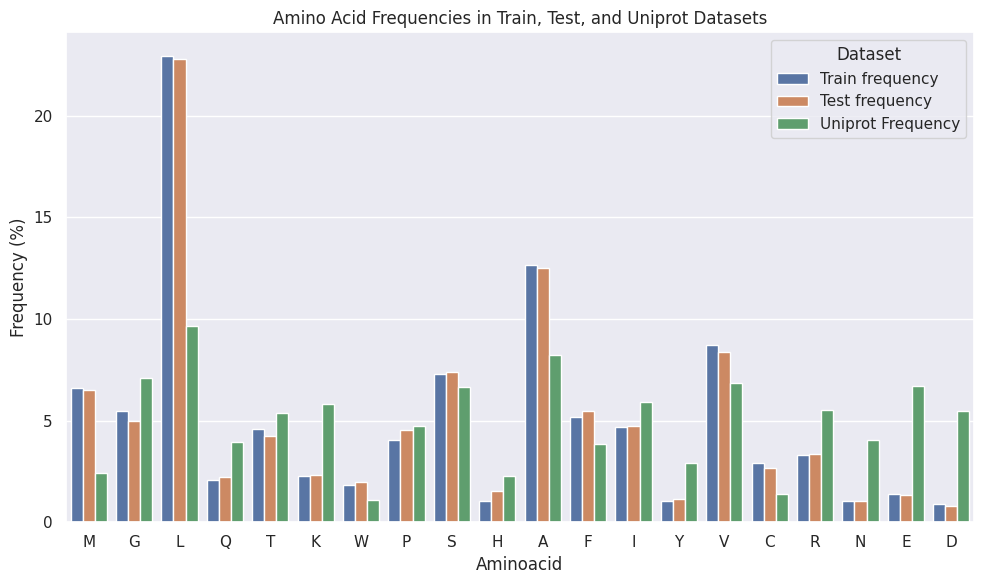

In [ ]:
# Training residues frequencies
df = pd.DataFrame(aa_count_train.items(), columns=['Aminoacid', 'Train frequency'])
df = df[df['Aminoacid'] != 'X']

# Test residues frequencies
df['Test frequency'] = df['Aminoacid'].map(aa_count_test)

# Uniprot residues frequencies
uniprot_res_freq = {
 'A': 8.25, 'Q': 3.93, 'L': 9.64, 'S': 6.65,
 'R': 5.52, 'E': 6.71, 'K': 5.80, 'T': 5.36,
 'N': 4.06, 'G': 7.07, 'M': 2.41, 'W': 1.10,
 'D': 5.46, 'H': 2.27, 'F': 3.86, 'Y': 2.92,
 'C': 1.38, 'I': 5.91, 'P': 4.74, 'V': 6.85
}

df['Uniprot Frequency'] = df['Aminoacid'].map(uniprot_res_freq)
df_melt = df.melt(id_vars='Aminoacid', var_name='Dataset', value_name='Frequency')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melt, x='Aminoacid', y='Frequency', hue='Dataset')

plt.title('Amino Acid Frequencies in Train, Test, and Uniprot Datasets')
plt.ylabel('Frequency (%)')
plt.xlabel('Aminoacid')
plt.legend(title='Dataset')

plt.tight_layout()
plt.show()

The code creates pie charts for the distribution of different categories (Kingdom and Organism) in the positive and negative training and test sets. It uses a dictionary of data and titles, where each key represents a dataset column (such as "Kingdom" or "Organism"), and each value is a list of categorical entries. It plots the top 8 most common categories for each dataset in a grid layout with a specified number of rows and columns. The resulting pie charts display the relative frequencies of the most common categories.

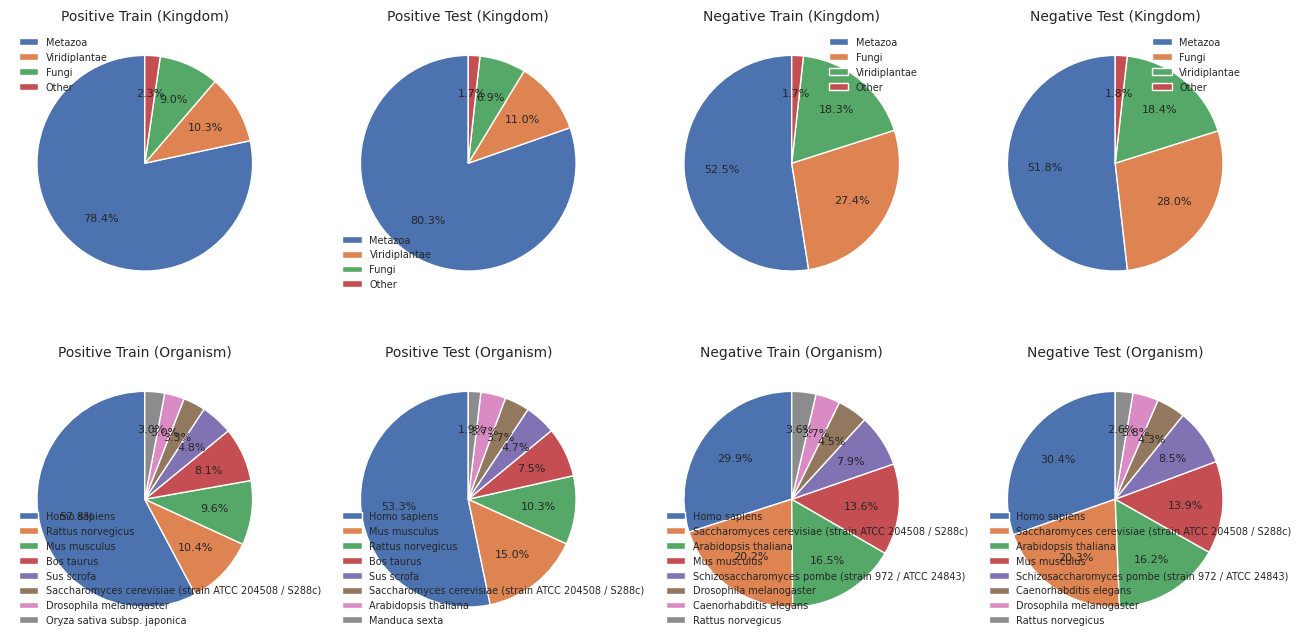

In [ ]:
def plot_pie(data_dict, titles, lim=8, rows=2, cols=4):
    fig, axs = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
    axs = axs.flatten()
    for i, (key, data) in enumerate(data_dict.items()):
        counter = Counter(data)
        most_common = counter.most_common(lim)
        labels, values = zip(*most_common)

        wedges, texts, autotexts = axs[i].pie(values,
                   labels=None,
                   startangle=90,
                   autopct='%1.1f%%',
                   textprops={'fontsize': 8},
                   pctdistance=0.65
                   )

        axs[i].legend(wedges, labels, loc="best", fontsize=7, frameon=False)
        axs[i].set_title(titles[i], fontsize=10)

    plt.show()

data_dict = {
    "pos_train_kingdom": pos_train['Kingdom'],
    "pos_test_kingdom": pos_test['Kingdom'],
    "neg_train_kingdom": neg_train['Kingdom'],
    "neg_test_kingdom": neg_test['Kingdom'],
    "pos_train_organism": pos_train['Organism'],
    "pos_test_organism": pos_test['Organism'],
    "neg_train_organism": neg_train['Organism'],
    "neg_test_organism": neg_test['Organism']
}

titles = [
    "Positive Train (Kingdom)", "Positive Test (Kingdom)",
    "Negative Train (Kingdom)", "Negative Test (Kingdom)",
    "Positive Train (Organism)", "Positive Test (Organism)",
    "Negative Train (Organism)", "Negative Test (Organism)"
]

plot_pie(data_dict, titles, lim=8, rows=2, cols=4)

The `write_motifs` function writes the first element of each tuple from the input dictionary to a file, each on a new line.

In [ ]:
def write_motifs(data, fasta):
  with open(fasta, 'w') as f:
    for seq in data.values():
      f.write(f'{seq[0]}\n')

In [ ]:
write_motifs(motif_train, 'motifs_train.txt')

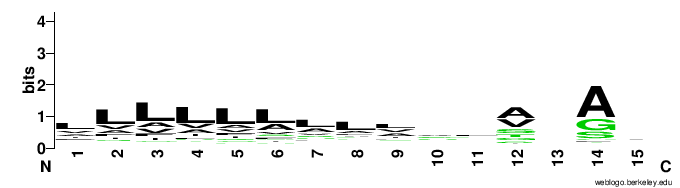

In [ ]:
write_motifs(motif_test, 'motifs_test.txt')

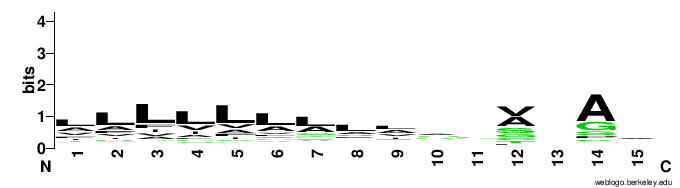

## 3) vonHeijne method for SP detection

The `one_hot` function encodes a protein sequence into a one-hot encoded matrix. Each amino acid in the sequence is represented by a row in a matrix of size `(len(seq), 20)`, where 1 indicates the presence of a specific amino acid (from `uniprot_res_freq`) at that position, and 0 otherwise.

In [ ]:
aa = list(uniprot_res_freq.keys())

def one_hot(seq):
  '''One-hot encode a proteic sequence'''

  one_hot = np.zeros((len(seq), 20), dtype=int)
  for i, res in enumerate(seq):
    if res in aa: # avoid non-std aa
      one_hot[i, aa.index(res)] = 1
  return one_hot

The `group_folds` function groups motifs by their corresponding fold. It iterates through the `data` dictionary (where the values are tuples of `(motif, fold)`) and returns a dictionary where the keys are fold identifiers, and the values are lists of motifs associated with each fold.

In [ ]:
def group_folds(data):
  '''Returns a {fold: motif} dictionary'''

  fold_dict = {}
  for motif, fold in data.values():
    if fold in fold_dict:
      fold_dict[fold].append(motif)
    else:
      fold_dict[fold] = [motif]
  return fold_dict

The `fasta_dict` function reads a FASTA file and returns a dictionary where the keys are the sequence IDs (extracted from the header lines) and the values are the corresponding protein sequences. It parses the file line by line, extracting the ID from the header line (lines starting with `>`) and the sequence from the subsequent lines.

In [ ]:
def fasta_dict(file):
  '''Returns a {id: sequence} dictionary'''

  dct = {}
  with open(file) as f:
    prev = None
    for line in f:
      if prev and prev.startswith('>'):
        id = prev.split('|')[1]
        dct[id] = line.strip()
      prev = line
  return dct

The `get_seq` function generates a dictionary of labels and corresponding sequences. It iterates over the rows of a DataFrame (`df`), and for each ID (from the DataFrame index), it yields a dictionary where the key is the label (from the `label` column) and the value is the sequence corresponding to that ID (from the `dct` dictionary). Optionally, it filters by a specific fold (via the `cv_fold` column), only yielding sequences for a given fold (`k`), or for all folds if `k` is `None`.

In [ ]:
def get_seq(df, dct, k=None):
  '''Yields a {label: sequence} dictionary'''

  for id in df.index:
    if k is None or df.at[id, 'cv_fold'] == k: # get all the entries or only the ones of a given fold
      yield {df.at[id, 'label']: dct[id]}

The `slide` function implements a sliding window approach. Given a sequence (`seq`) and a window size (`size`), it iterates over the sequence and yields subsequences of length `size` starting from each position in the sequence. The window slides one position at a time, yielding overlapping subsequences until the end of the sequence is reached. The function ensures that the subsequences have the specified length by checking the available range (`len(seq) - size + 1`).

In [ ]:
def slide(seq, size):
  '''Sliding window'''

  start, end = 0, 90 # first N-terminal positions
  for i in range(len(seq)-size+1):
    yield seq[i:i+size]

The `get_mx` function generates a Position-Specific Weight Matrix (PSWM) for a set of motifs (protein sequences). Here's how it works:

1. **Initialization**:
   - It creates an empty matrix `mx` where rows correspond to specific positions in the motif (-13 to +2, excluding 0), and columns correspond to amino acids (`aa`).
   - Each position is initialized with a value of 1.

2. **Matrix Update**:
   - The function sums one-hot encoded versions of the motifs from the selected folds (`i_s`), where `folds[i]` is a list of motifs for fold `i`.
   - It then normalizes the matrix by the total number of motifs in the selected folds, plus a smoothing factor to handle amino acids not observed in the current data (using 20 for each fold).
   - The matrix is further adjusted by dividing by the amino acid frequencies from `uniprot_res_freq`.

3. **Log Transformation**:
   - The matrix values are transformed using a log scale to reduce the range of values, making the matrix more interpretable for downstream applications like machine learning.

The result is a log-transformed PSWM that reflects the amino acid preferences at each position within the motifs, normalized to account for overall amino acid frequencies.

In [ ]:
def get_mx(folds, i_s):
  '''Returns an updated PSWM matrix'''

  # initialize the matrix
  pos = [str(n) for n in range(-13, 3) if n != 0] # rows

  mx = pd.DataFrame(1, index=pos, columns=aa)
  mx.index.name = 'Position'
  mx.columns.name = 'Amino acid'

  # update the matrix
  mx += sum(one_hot(motif) for i in i_s for motif in folds[i])
  mx /= (sum(len(folds[i]) for i in i_s) + 20*len(i_s))
  mx /= pd.Series(uniprot_res_freq)/100

  return mx.apply(np.log)

The `get_scores` function calculates the maximum score for each sequence using a Position-Specific Weight Matrix (PSWM):

1. For each sequence, it slides a 15-amino acid window.
2. Each subsequence is one-hot encoded, and its score is computed by summing the PSWM values.
3. The highest score for each sequence is tracked and returned as a list.

In [ ]:
def get_scores(mx, seqs):
  '''Returns a list of max scores for each sequence'''

  scores = []
  for seq in seqs:
    max = -np.inf
    for subseq in slide(seq, 15): # sliding window size = 15
      mask = one_hot(subseq).astype(bool)
      score = np.sum(mx.values[mask])
      if score > max:
        max = score
    scores.append(max)
  return scores

A function for computing the standard error by dividing the standard deviation by the square root of the number of values.

In [ ]:
def std_err(values):
    std = np.std(values)
    n = len(values)
    se = std / np.sqrt(n)
    return se

The function `vh_pred` predicts signal peptides (SPs) using the von Heijne method. It performs the following steps:

1. **Training Phase**:
   - Divides the data into `k` folds for cross-validation.
   - For each fold, it trains a Position-Specific Weight Matrix (PSWM) using motifs from the training set (train and test sets combined).
   - Calculates optimal thresholds using the precision-recall curve for each fold and stores them.

2. **Testing Phase**:
   - Uses the trained PSWM matrix and the final test set to predict SPs.
   - Determines the final predictions using the optimal threshold mean.

The function also calculates and prints the optimal thresholds for each fold, and the average optimal threshold with its standard error.



In [ ]:
def vh_pred(k=5):
  '''Predicts SPs using the vonHeijne method'''

  fasta = 'pos+neg.fasta'
  fasta_dct = fasta_dict(fasta)

  ############## TRAINING PHASE ##############

  folds = [i for i in range(k)]
  opt_ths = []

  for i in range(k):

    test_i = i
    val_i = (i+1) % k
    train_i = [f for f in folds if f != test_i and f != val_i] # a list of indexes

    # Both motifs from train and test set are used as training set
    mx = get_mx(group_folds(motif_train | motif_test), train_i)

    val_data = (
      (
          next(iter(label)), # pos/neg labels
          next(iter(label.values())) # sequences
      ) for label in get_seq(val_cv, fasta_dct, val_i)
      )

    y_true, seqs = zip(*val_data)

    val_scores = get_scores(mx, seqs)

    p, r, ths = precision_recall_curve(np.array(y_true), val_scores)
    f1_score = 2*p*r/(p+r)
    index = np.argmax(f1_score)
    opt_th = ths[index]
    opt_ths.append(opt_th)

  opt_th = sum(opt_ths)/k # optimal thresholds mean

  ############## TESTING PHASE ##############

  mx = get_mx(group_folds(motif_final_train), folds)
  mx.to_csv('PSWM.csv')

  final_test_data = (
      (
          next(iter(label)), # pos/neg labels
          next(iter(label.values())) # sequences
      ) for label in get_seq(final_test_cv, fasta_dct)
      )

  y_true, seqs = zip(*final_test_data)

  test_scores = get_scores(mx, seqs)
  y_pred = [int(t_s >= opt_th) for t_s in test_scores]

  final_test_cv['vh_y_true'] = y_true
  final_test_cv['vh_y_pred'] = y_pred

  print('######## von Heijne results ########')
  print('\nOptimal thresholds:')
  for i, thr in enumerate(opt_ths):
    print(f'Fold {i+1}: {thr:.2f}')
  print(f'\nOptimal threshold mean = {opt_th:.2f} ± {std_err(opt_ths):.2f}')

  return y_true, y_pred

The `get_metrics` function calculates and visualizes classification metrics based on the confusion matrix:

1. **Metrics**: Precision, Recall, Specificity, F1 Score, Accuracy, MCC, FPR, FNR, and FDR.
2. **Visualization**: Displays a heatmap of the confusion matrix.
3. **Output**: Prints all metrics for model evaluation.

It helps assess a binary classifier's performance.

In [ ]:
def get_metrics(y_true, y_pred):
  '''Returns the metrics'''

  cm = np.zeros((2, 2))

  for true, pred in zip(y_true, y_pred):
    cm[true, pred] += 1 # confusion matrix

  tn, fp, fn, tp = cm.ravel()

  p = tp/(tp+fp) # precision
  r = tp/(tp+fn) # recall
  s = tn/(tn+fn) # specificity
  f1 = 2*p*r/(p+r) # f1 score
  acc = (tp+tn)/(tp+tn+fp+fn) # accuracy
  mcc = (tp*tn-fp*fn)/np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn)) # mcc
  fpr = fp/(fp+tn) # false positive rate
  fnr = fn/(tp+fn) # false negative rate
  fdr = fp/(tp+fp) # false discovery rate

  # Visualization

  plt.figure(figsize=(8, 6))
  sns.heatmap(
      cm,
      annot=True,
      fmt='',
      cmap='Blues',
      xticklabels=['Negative', 'Positive'],
      yticklabels=['Negative', 'Positive']
      )
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.title('Confusion Matrix')
  plt.show()

  print(f'\nPrecision = {p:.2f}')
  print(f'Recall = {r:.2f}')
  print(f'Specificity = {s:.2f}')
  print(f'F1 Score = {f1:.2f}')
  print(f'Accuracy = {acc:.2f}')
  print(f'MCC = {mcc:.2f}')
  print(f'False Positive Rate = {fpr:.2f}')
  print(f'False Negative Rate = {fnr:.2f}')
  print(f'False Discovery Rate = {fdr:.2f}')

This code redirects the output of `get_metrics(*vh_pred())` to `'vh_results.txt'` and measures execution time with `%%time`.

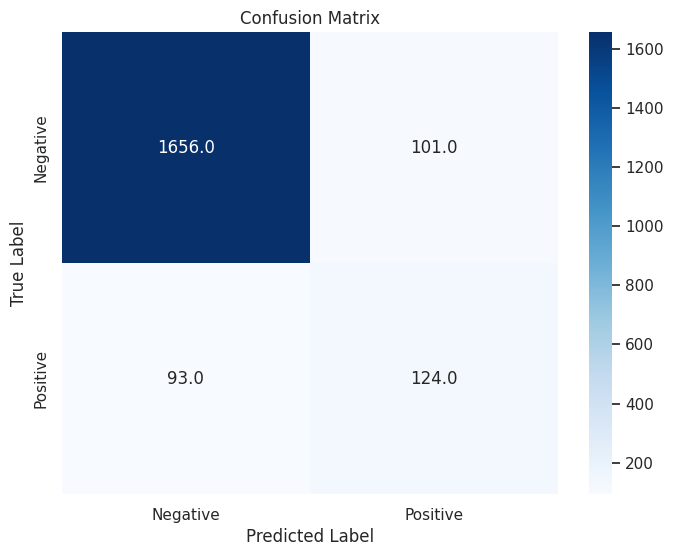

CPU times: user 42.9 s, sys: 3.21 s, total: 46.1 s
Wall time: 46 s


In [ ]:
%%time
with open('vh_results.txt', 'w') as f:
  std_out = sys.stdout
  sys.stdout = f
  get_metrics(*vh_pred())
  sys.stdout = std_out

## 4) Support Vector Machine for SP detection

The `extract_features` function extracts five key features from protein sequences in a FASTA file to represent signal peptides in a D-dimensional space:

1. **Amino acid frequencies** (first 22 positions)
2. **Hydropathy** (Kite-Doolittle scale)
3. **Charged amino acid content** (3-residue window)
4. **Alpha-helix propensity** (Chou-Fasman scale)
5. **Transmembrane propensity** (Zhao-London scale)

For each protein, the features are computed, stored in a dictionary, and then converted into a DataFrame. The DataFrame is labeled and split into training/validation folds using `cross_val`. The function returns this DataFrame for further analysis.

In [ ]:
%%capture

def extract_features(data, fasta, pos=40):
  '''Extracts features for SP representation in D-dimensional space'''

  # Initialization
  features = {}

  with open(fasta) as f:
    prev = None

    for line in f:
      if prev and prev.startswith('>'):
        id = prev.split('|')[1]
        if id in data.index:

          seq = line[:pos].strip()
          features[id] = {}

          # feature 1 - aa freqs
          c = Counter({a: 0 for a in 'ARNDCQEGHILKMFPSTWYV'})
          c.update(seq[:22])  # first 22 positions
          freq = pd.Series(c)/sum(c.values())
          features[id].update(freq.to_dict())

          # feature 2 - Kite-Doolittle hydropathy
          kd = ProteinAnalysis('X'*2 + seq + 'X'*2).protein_scale(ProtParamData.kd, 5)
          features[id]['Max_Hydrophobicity'] = max(kd)
          features[id]['Mean_Hydrophobicity'] = sum(kd)/len(kd)

          # feature 3 - charged aa
          scale = {
              'A': 0, 'R': 1, 'N': 0, 'D': -1, 'C': 0,
              'Q': 0, 'E': -1, 'G': 0, 'H': 0, 'I': 0,
              'L': 0, 'K': 1, 'M': 0, 'F': 0, 'P': 0,
              'S': 0, 'T': 0, 'W': 0, 'Y': 0, 'V': 0
              }
          ch = ProteinAnalysis('X' + seq + 'X').protein_scale(scale, 3)
          features[id]['Max_Charged'] = max(ch)
          features[id]['Mean_Charged'] = sum(ch)/len(ch)

          # feature 4 - Chou-Fasman alpha-helix propensity
          scale = {
              'A': 1.420, 'R': 0.980, 'N': 0.670, 'D': 1.010,
              'C': 0.700, 'Q': 1.110, 'E': 1.510, 'G': 0.570,
              'H': 1.000, 'I': 1.080, 'L': 1.210, 'K': 1.160,
              'M': 1.450, 'F': 1.130, 'P': 0.570, 'S': 0.770,
              'T': 0.830, 'W': 1.080, 'Y': 0.690, 'V': 1.060
              }
          alph = ProteinAnalysis('X'*3 + seq + 'X'*3).protein_scale(scale, 7)
          features[id]['Max_AlphaHelix_Propensity'] = max(alph)
          features[id]['Mean_AlphaHelix_Propensity'] = sum(alph)/len(alph)

          # feature 5 - Zhao-London transmembrane propensity
          scale = {
              'A': 0.380, 'R': -2.570, 'N': -1.620, 'D': -3.270,
              'C': -0.300, 'Q': -1.840, 'E': -2.900, 'G': -0.190,
              'H': -1.440, 'I': 1.970, 'L': 1.820, 'K': -3.460,
              'M': 1.400, 'F': 1.980, 'P': -1.440, 'S': -0.530,
              'T': -0.320, 'W': 1.530, 'Y': 0.490, 'V': 1.460
              }
          trans = ProteinAnalysis('X'*3 + seq + 'X'*3).protein_scale(scale, 7)
          features[id]['Max_Transmembrane_Propensity'] = max(trans)
          features[id]['Mean_Transmembrane_Propensity'] = sum(trans)/len(trans)

      prev = line

    df = pd.DataFrame.from_dict(features, orient='index')
    df['label'] = data.loc[df.index, 'label'] # add the labels
    df.index.name = 'Accession'
    df = cross_val(df) # already divide in folds
    df.drop('X', axis=1, inplace=True, errors='ignore')

    return df

train_feat = extract_features(train_cv, 'pos+neg.fasta')
val_feat = extract_features(val_cv, 'pos+neg.fasta')
test_feat = extract_features(test_cv, 'pos+neg.fasta')

final_train_feat = extract_features(final_train_cv, 'pos+neg.fasta')
final_test_feat = extract_features(final_test_cv, 'pos+neg.fasta')

The `extract_data` function extracts features and labels from a DataFrame `df`:

1. **Base Features**: First 20 columns (feature 1).
2. **Additional Features**: Four lists of columns for hydrophobicity, charge, alpha-helix, and transmembrane propensity.
3. **Labels**: `label` and `cv_fold` columns.

It returns the base features, additional features, and labels.

In [ ]:
def extract_data(df):

  base = df.iloc[:, :20]  # feature 1

  feat = [
      df[['Max_Hydrophobicity', 'Mean_Hydrophobicity']],  # feature 2
      df[['Max_Charged', 'Mean_Charged']],  # feature 3
      df[['Max_AlphaHelix_Propensity', 'Mean_AlphaHelix_Propensity']],  # feature 4
      df[['Max_Transmembrane_Propensity', 'Mean_Transmembrane_Propensity']]  # feature 5
      ]

  labels = df[['label', 'cv_fold']]

  return (base, feat, df['cv_fold']), labels

The `combine_features` function generates all possible combinations of features from `base` and `feat` along with the `folds`. It:

1. Iterates over all combinations of `feat` (from 0 to all).
2. Concatenates the `base`, selected features, and `folds`.
3. Yields the concatenated DataFrame for each combination of features.

In [ ]:
def combine_features(base, feat, folds):

  for r in range(len(feat)+1):
    for comb in itertools.combinations(range(len(feat)), r):
      X = pd.concat([base] + [feat[i] for i in comb] + [folds], axis=1)
      yield X

Thisfunction maps feature names to acronyms and returns a set of acronyms for the given features.

In [ ]:
def translate_features(features):
  '''Translate the features name into an acronym'''

  acronyms = {
      'Amino_acid_frequencies': 'AA',
      'Max_Hydrophobicity': 'HP',
      'Mean_Hydrophobicity': 'HP',
      'Max_Charged': 'CH',
      'Mean_Charged': 'CH',
      'Max_AlphaHelix_Propensity': 'AH',
      'Mean_AlphaHelix_Propensity': 'AH',
      'Max_Transmembrane_Propensity': 'TM',
      'Mean_Transmembrane_Propensity': 'TM'
      }

  return set([acronyms[f] for f in features])

The `svm_pred` function trains and evaluates a Support Vector Machine (SVM) classifier on feature combinations for predicting protein properties.

1. **Training Phase:**
  - **Data Preparation**: The function extracts features for training, validation, and test sets using `extract_data`.
  - **Hyperparameter Tuning**: A grid search is performed over hyperparameters (`C` and `gamma`) using k-fold cross-validation to find the best SVM model configuration.
  - **Feature Combinations**: Different combinations of features are tested. For each combination, the model is trained and evaluated using the Matthews Correlation Coefficient (MCC).
  - **Best Model Selection**: The feature combination and SVM parameters that yield the highest MCC are stored.

2. **Testing Phase:**
  - **Final Training**: The model is retrained using the selected feature combination and best hyperparameters on the full training set.
  - **Testing**: The model is evaluated on the final test set.
  - **Results**: The function prints the best feature combination, SVM hyperparameters, and MCC results, and returns true and predicted labels for the test set.



In [ ]:
def svm_pred(kernel_type='rbf', k=5):

  ############## TRAINING PHASE ##############

  print(f'######## SVM with {kernel_type} kernel results ########')
  print("\nMCCs of different feature combinations' predictions:\n")

  # SVM hyperparameters
  C = {1.0, 2.0, 4.0, 8.0}
  G = {0.5, 1.0, 2.0, 'scale'}

  # Generate the data by feature combinations
  d = [
        extract_data(train_feat),
        extract_data(val_feat),
        extract_data(test_feat)
    ]

  data = [data[0] for data in d]
  labels = [data[1] for data in d]

  # Initialize the values for selecting the best combination of features
  top_mcc, cnt = float('-inf'), 0
  top_cnt, top_feat, top_c, top_g = None, None, None, None

  # Iterate over all possible feature combinations
  for X_train, X_val, X_test in zip(combine_features(*data[0]),  # training (base, features)
                                    combine_features(*data[1]),  # validation //
                                    combine_features(*data[2])): # testing //

    mccs = []

    features = ['Amino_acid_frequencies'] + [
        col for col in X_train.columns
        if col not in 'ARNDCQEGHILKMFPSTWYVcv_fold'
        ]

    # k-fold cv for optimizing the SVM's C and gamma hyperparameters
    folds = [i for i in range(k)]
    params = {}

    for i in range(k):

      # Initialization of data and labels
      test_i = i
      test = X_test.query('cv_fold == @test_i').iloc[:, :-1]
      labels_test = labels[2].query('cv_fold == @test_i')['label'].values

      val_i = (i+1) % k
      val = X_val.query('cv_fold == @val_i').iloc[:, :-1]
      labels_val = labels[1].query('cv_fold == @val_i')['label'].values

      train_i = [f for f in folds if f != test_i and f != val_i]
      train = X_train.query('cv_fold in @train_i').iloc[:, :-1]
      labels_train = labels[0].query('cv_fold in @train_i')['label'].values

      # Optimization
      scaler = preprocessing.MinMaxScaler().fit(train)

      X_tr = scaler.transform(train)
      X_v = scaler.transform(val)

      best_mcc = float('-inf')
      best_params = None
      for c, g in itertools.product(C, G): # grid search
        spSVC = svm.SVC(C=c, gamma=g, kernel=kernel_type)
        spSVC.fit(X_tr, labels_train)

        y_pred = spSVC.predict(X_v)
        mcc = matthews_corrcoef(labels_val, y_pred)

        if mcc > best_mcc:
          best_mcc = mcc
          best_c, best_g = c, g

      # Store the best hyperparameters in a dictionary {fold: (c, g)}
      params[i] = (best_c, best_g)

      # Testing
      X_te = scaler.transform(test)

      spSVC = svm.SVC(C=best_c, gamma=best_g, kernel=kernel_type)
      spSVC.fit(X_tr, labels_train) # get an optimal training

      y_pred = spSVC.predict(X_te)
      mccs.append(matthews_corrcoef(labels_test, y_pred))

    # select the most frequent parameters among the cv runs
    # in case of tie, the smallest one is selected
    c_s, g_s = zip(*params.values())
    c_cnts, g_cnts  = Counter(c_s), Counter(g_s)

    c = min(c_cnts, key=lambda x: (-c_cnts[x], x))
    g = min(
        g_cnts,
        key=lambda x: (
         -g_cnts[x],
         x
          # ignore scale if it's the most frequent together with other values
          ) if isinstance(x, (int, float)) else (float('inf'), x)
         )

    # the mcc for this feature combination is the mean of the mccs from each cv run
    mcc = sum(mccs)/len(mccs)
    print(f'({cnt+1}) {translate_features(features)}: {mcc:.2f} ± {std_err(mccs):.2f}')

    # find the best feature combination
    if mcc > top_mcc:
      top_mcc = mcc
      top_cnt = cnt
      top_feat = features
      top_c, top_g = c, g

    cnt += 1
  ############## TESTING PHASE ##############

  d = [
      extract_data(final_train_feat),
      extract_data(final_test_feat)
      ]

  data = [data[0] for data in d]
  labels = [data[1] for data in d]

  # This method exactly selects the best feature combination
  gen = itertools.islice(combine_features(*data[0]), top_cnt, top_cnt+1)

  X_train = next(gen)
  final_train_cv[top_feat[1:]] = X_train.iloc[:, 20:-1]

  scaler = preprocessing.MinMaxScaler().fit(X_train)
  X_train = scaler.transform(X_train)

  spSVC = svm.SVC(C=top_c, gamma=top_g, kernel=kernel_type)
  spSVC.fit(X_train, labels[0]['label'].values)

  # The same feature combination is used for the test set
  gen = itertools.islice(combine_features(*data[1]), top_cnt, top_cnt+1)

  X_test = next(gen)
  final_test_cv[top_feat[1:]] = X_test.iloc[:, 20:-1]

  X_test = scaler.transform(X_test)

  y_true = labels[1]['label']
  y_pred = spSVC.predict(X_test)

  final_test_cv['svm_y_true'] = y_true
  final_test_cv['svm_y_pred'] = y_pred

  # Print the results
  print('\nTraining phase results:\n')
  print(f"Best feature combination's MCC = {top_mcc:.2f} ± {std_err(mccs):.2f}")
  print(f'Best SVM hyperparameters: C = {top_c}, gamma = {top_g}')
  print(f'Best combination of features: ({top_cnt+1}) {translate_features(top_feat)}')
  print('\nTesting phase results:')

  return y_true, y_pred

In [ ]:
%%time
get_metrics(*svm_pred())

######## SVM with rbf kernel results ########

MCCs of different feature combinations' predictions:

(1) {'AA'}: 0.76 ± 0.03
(2) {'HP', 'AA'}: 0.77 ± 0.02


This code times the execution of svm_pred, redirects output to svm_results.txt, and then restores the standard output. Results are saved to svm_results.txt.

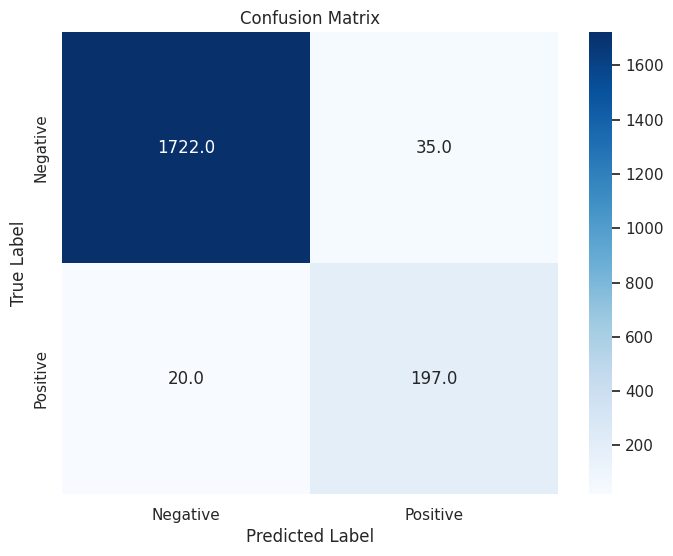

CPU times: user 1min 53s, sys: 207 ms, total: 1min 53s
Wall time: 1min 54s


In [ ]:
%%time
with open('svm_results.txt', 'w') as f:
  std_out = sys.stdout
  sys.stdout = f
  get_metrics(*svm_pred())
  sys.stdout = std_out

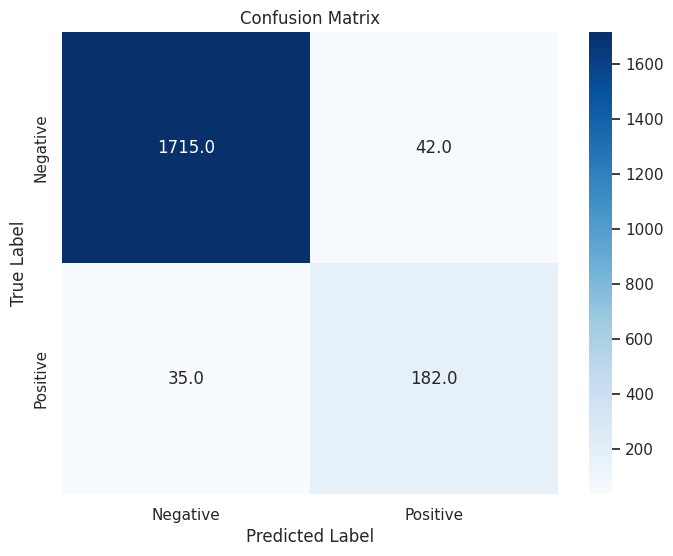

CPU times: user 1min 21s, sys: 304 ms, total: 1min 21s
Wall time: 1min 22s


In [ ]:
%%time
with open('linear_svm_results.txt', 'w') as f:
  std_out = sys.stdout
  sys.stdout = f
  get_metrics(*svm_pred('linear'))
  sys.stdout = std_out

linear


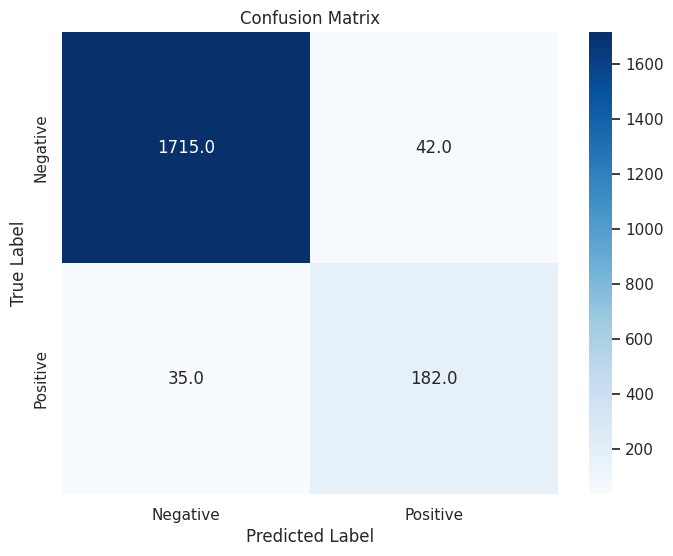

poly


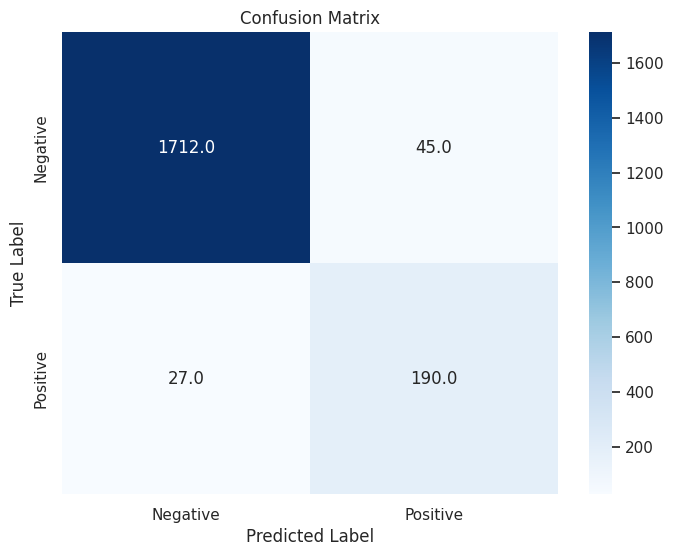

sigmoid


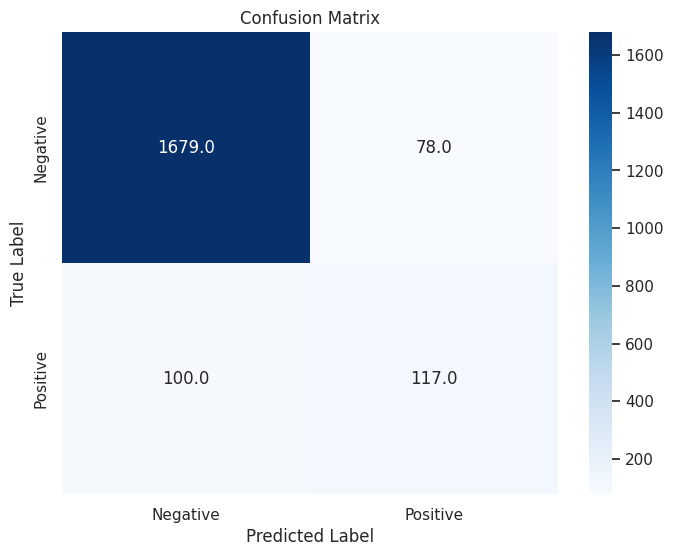

precomputed


In [ ]:
%%time
for kernel in ['linear', 'poly', 'sigmoid', 'precomputed']:
  print(kernel)
  with open(f'{kernel}_svm_results.txt', 'w') as f:
    std_out = sys.stdout
    sys.stdout = f
    get_metrics(*svm_pred(kernel))
    sys.stdout = std_out

## 5) False predictions analysis

The code checks if the true labels (`label`) match the predicted labels (`vh_y_true` and `svm_y_true`) in the `final_test_cv` DataFrame and prints `True` or `False`.

In [ ]:
df = final_test_cv.copy()
# Check if the true labels are equal to the labels
print(df['label'].equals(df['vh_y_true']))
print(df['label'].equals(df['svm_y_true']))

True
True


The code segments extract the true positive (TP), false positive (FP), false negative (FN), and true negative (TN) values for both the von Heijne (vh) and SVM predictions by comparing the true labels (`label`) with the predicted labels (`vh_y_pred` and `svm_y_pred`). These values are stored in separate DataFrames for further analysis.

In [ ]:
# von Heijne
vh_tp = df[(df['label'] == 1) & (df['vh_y_pred'] == 1)]
vh_fp = df[(df['label'] == 0) & (df['vh_y_pred'] == 1)]
vh_fn = df[(df['label'] == 1) & (df['vh_y_pred'] == 0)]
vh_tn = df[(df['label'] == 0) & (df['vh_y_pred'] == 0)]

# SVM
svm_tp = df[(df['label'] == 1) & (df['svm_y_pred'] == 1)]
svm_fp = df[(df['label'] == 0) & (df['svm_y_pred'] == 1)]
svm_fn = df[(df['label'] == 1) & (df['svm_y_pred'] == 0)]
svm_tn = df[(df['label'] == 0) & (df['svm_y_pred'] == 0)]

The code calculates and compares the false positive rates (FPR) for von Heijne (vh) and SVM predictions, both for all sequences and specifically for sequences with helix positions (`HelixStartPos<90`).

- **FPR Calculation**: The FPR is computed as the ratio of false positives (FP) over the total of false positives and true negatives (TN), multiplied by 100 for percentage.
- **Helix-based FPR**: The false positives and true negatives are filtered to include only sequences with helix positions (`HelixStartPos<90`), and the FPR is recalculated for this subset.

Results are saved to a file `false_positive_analysis.txt`, displaying the FPRs for both models (vh and SVM), for all sequences and for those with helix sequences.

In [ ]:
helix_set = set(df[df['HelixStartPos<90']==True].index)

vh_fp_hel = set(vh_fp.index) & helix_set
vh_tn_hel = set(vh_tn.index) & helix_set

svm_fp_hel = set(svm_fp.index) & helix_set
svm_tn_hel = set(svm_tn.index) & helix_set

vh_fpr = len(vh_fp)/(len(vh_fp)+len(vh_tn))*100
vh_fpr_hel = len(vh_fp_hel)/(len(vh_fp_hel)+len(vh_tn_hel))*100

svm_fpr = len(svm_fp)/(len(svm_fp)+len(svm_tn))*100
svm_fpr_hel = len(svm_fp_hel)/(len(svm_fp_hel)+len(svm_tn_hel))*100

with open('false_positive_analysis.txt', 'w') as f:
  std_out = sys.stdout
  sys.stdout = f
  print('False positive analysis:')

  print('\nvon Heijne:')
  print(f'FPR: {vh_fpr:.2f}%')
  print(f'FPR with helix sequences: {vh_fpr_hel:.2f}%')

  print('\nSVM:')
  print(f'FPR: {svm_fpr:.2f}%')
  print(f'FPR with helix sequences: {svm_fpr_hel:.2f}%')
  sys.stdout = std_out

This code writes the motif_final_test data to a text file named motifs_final_test.txt using the write_motifs function. Then, the file is used for computing the sequence logo.

In [ ]:
# von Heijne expected motif logo
write_motifs(motif_final_test, 'motifs_final_test.txt')

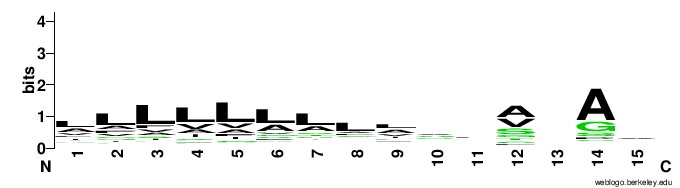

The same for the von Heijne false negatives data.

In [ ]:
# von Heijne FN motif logo
_, motif_vh_fn = sp_info(vh_fn)
write_motifs(motif_vh_fn, 'motifs_vh_fn.txt')

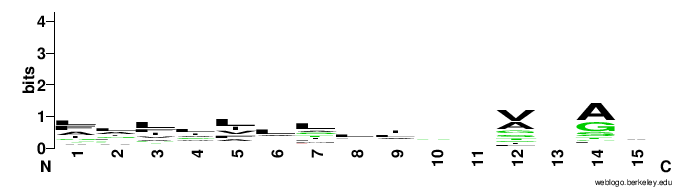

The code defines a function `n_term_info` that calculates the normalized frequency of amino acids in the first `pos` residues of sequences from a FASTA file, based on sequence IDs in the `data` index. It then filters the `final_train_cv` dataset for positive samples (`label == 1`) and extracts amino acid frequencies for the training set using `sp_info`. The resulting DataFrame is expanded to include amino acid frequencies for SVM true positives and false negatives. The data is melted for visualization, and a bar plot is generated to compare amino acid frequencies across the training set, SVM true positives, and SVM false negatives. The plot helps visualize differences in amino acid distributions across these datasets.

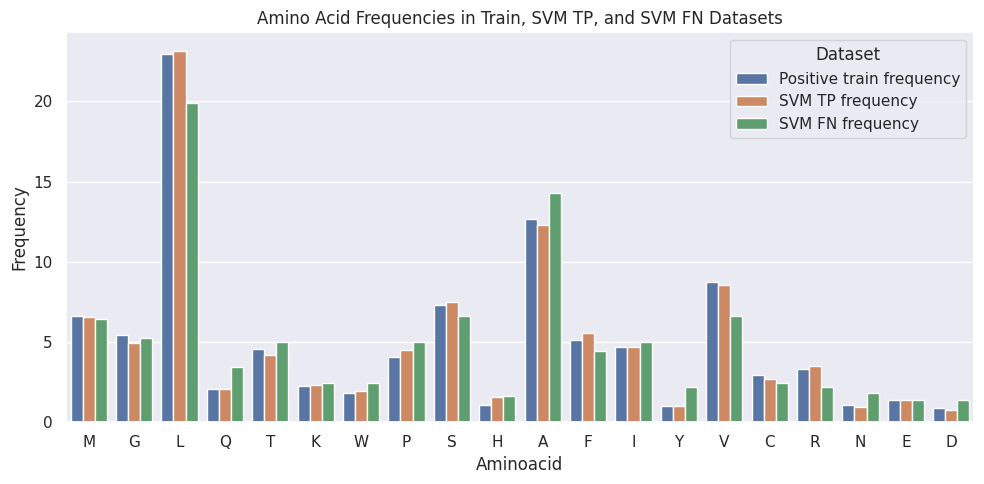

In [ ]:
def n_term_info(data, pos=90, fasta='pos+neg.fasta'):

  # Initialize the dictionary
  counter = Counter()

  # Update the dictionary
  with open(fasta) as f:
    prev = None

    for line in f:
      if prev and prev.startswith('>'):
        id = prev.split('|')[1]
        if id in data.index:

          # update the counter
          seq = line[:pos].strip()
          counter.update(seq)

      prev = line

  tot = sum(counter.values())

  return {k: v/tot for k, v in counter.items()}

fts = final_train_cv[final_train_cv['label'] == 1]

df = pd.DataFrame(
    sp_info(fts)[0].items(),
    columns=['Aminoacid', 'Positive train frequency']
    ) # aa frequencies of SVM training set

df['SVM TP frequency'] = df['Aminoacid'].map(sp_info(svm_tp)[0]) # // of SVM TP
df['SVM FN frequency'] = df['Aminoacid'].map(sp_info(svm_fn)[0]) # // of SVM FN

df = df[~df['Aminoacid'].isin(['X', 'U'])] # remove X and U amino acids
df_melt = df.melt(id_vars='Aminoacid', var_name='Dataset', value_name='Frequency')

plt.figure(figsize=(10, 5))
sns.barplot(data=df_melt, x='Aminoacid', y='Frequency', hue='Dataset')

plt.title('Amino Acid Frequencies in Train, SVM TP, and SVM FN Datasets')
plt.ylabel('Frequency')
plt.xlabel('Aminoacid')
plt.legend(title='Dataset')

plt.tight_layout()
plt.show()

This code concatenates three datasets - `fts`, `svm_tp`, and `svm_fn` - into a single DataFrame `df`, each labeled with a corresponding "Dataset" column ('Positive train set', 'SVM TP set', 'SVM FN set'). It then selects columns containing 'Max' or 'Mean' in their names, as well as the 'SignalPeptideCleavageSite' column, and assigns these columns to `cols`. Using `seaborn`, the code creates a set of box plots to compare the distribution of these selected features across the three datasets. The plots are displayed in a 4x2 grid, where each subplot represents the distribution of a specific feature. The unused axes are removed, and the layout is adjusted for a clean presentation.

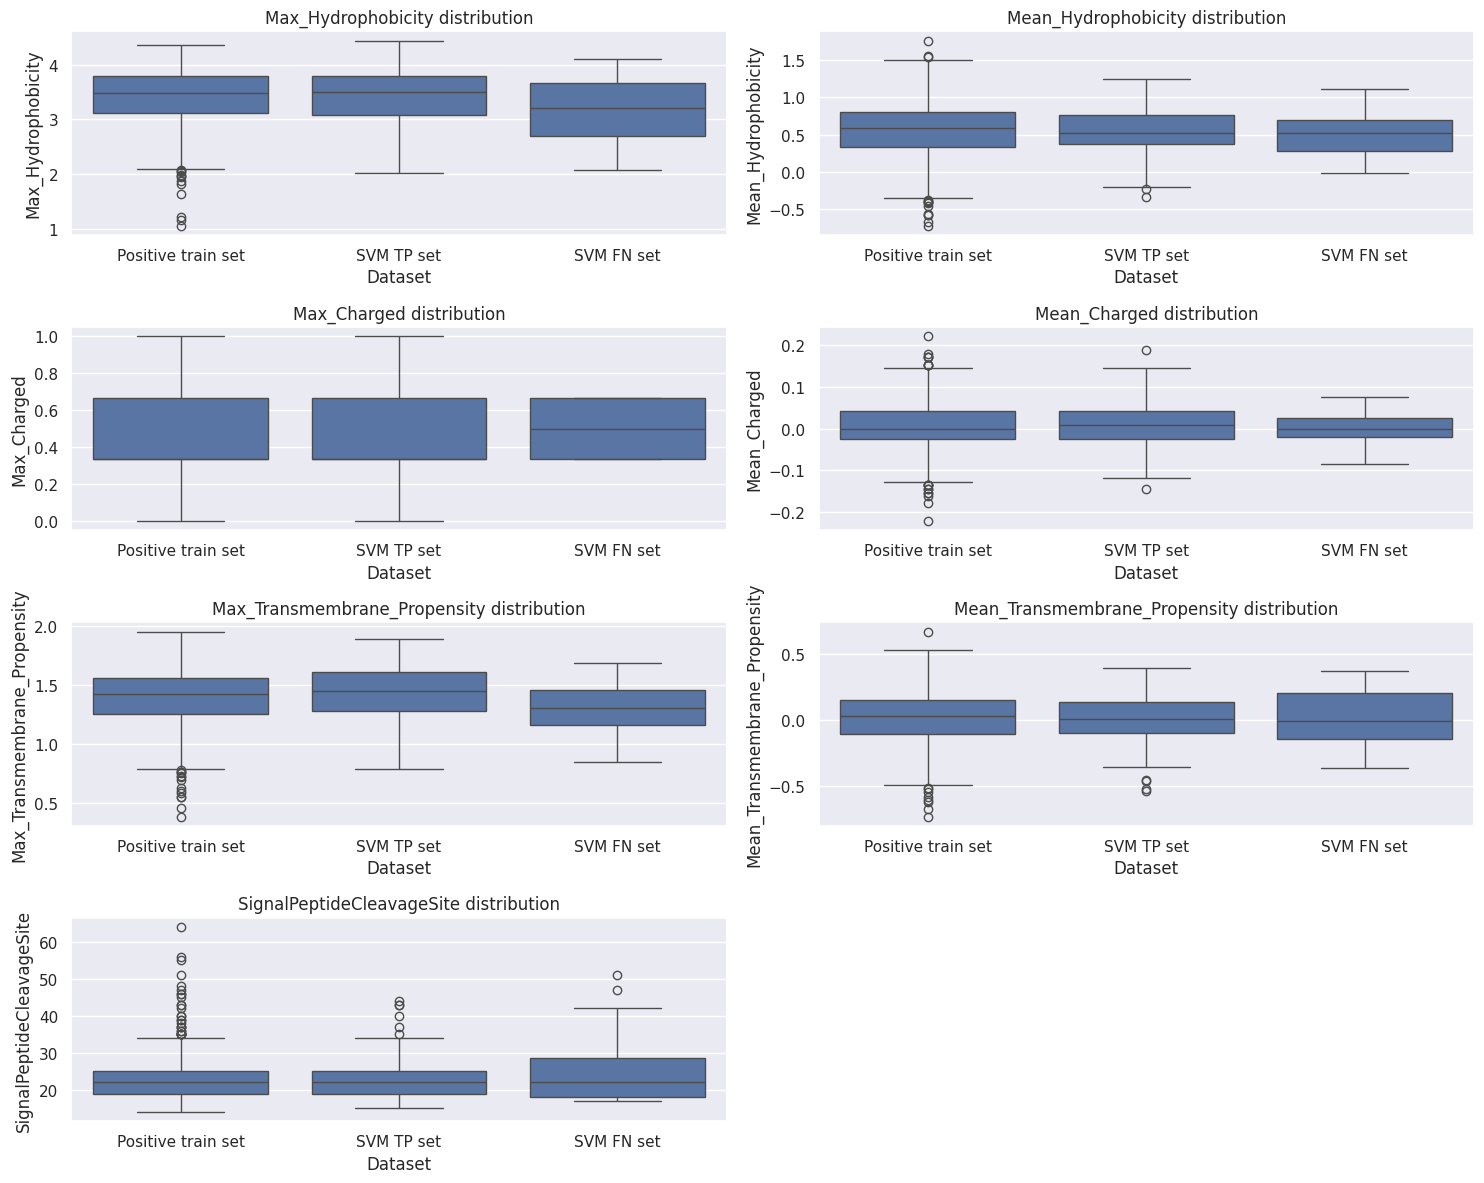

In [ ]:
df = pd.concat([
    fts.assign(Dataset='Positive train set'),
    svm_tp.assign(Dataset='SVM TP set'),
    svm_fn.assign(Dataset='SVM FN set')
    ])

cols = [col for col in df.columns if 'Max' in col or 'Mean' in col]
cols.append('SignalPeptideCleavageSite')

fig, axes = plt.subplots(4, 2, figsize=(15, 12))

axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(x='Dataset', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} distribution')
    axes[i].set_ylabel(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()